<a href="https://colab.research.google.com/github/mauracarter-statistics/csc162/blob/main/carter_maura_module4_save_reload_models1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Maura Carter**

**Module #3 Assignment; CSC 161; February 22, 2026.**

**INSTRUCTIONS**

In this assignment, you will build, train, save, and reload a simple TensorFlow model using synthetic baseball data. The generated data simulates basic pitch information (e.g., horizontal and vertical coordinates) and a binary outcome indicating whether the pitch is a “strike” or a “ball.” You will perform the following tasks:

**1. Generate a synthetic baseball dataset.**

**2. Create a simple neural network model for binary classification.**

**3. Train the model on the generated data.**

**4. Save the complete model (architecture, weights, and optimizer state) and also save just the weights.**

**5. Reload the saved full model and evaluate its performance on test data.**

**6. Recreate the model architecture and load only the saved weights; then verify performance.**

The goal of this activity is to reinforce your ability to persist trained models for reproducibility, deployment, or continued training.

Review:

If needed, review the following lecture:

Video - Saving and Reloading Trained TensorFlow Models Lecture: https://youtu.be/fyopdXAsvN8

***CODE/PROGRAMMING***

**Pre-Step:**

**Import necessary packages/libraries.** This is always the first step when starting to code, because most of the code won't work or you'll get errors if you're using functions from a package/library that isn't loaded.

In [49]:
import tensorflow as tf
from tensorflow import keras
import numpy as np

**INSTRUCTIONS**

**1. Setup and Data Generation**
**Objective:** Create synthetic baseball data with features representing the pitch location on home plate.

**Dataset Details:**

**Features:** Two features representing the x-coordinate (horizontal position) and y-coordinate (vertical position) of a pitch.

**Target:** A binary label where “1” represents a strike and “0” represents a ball.

**Samples:** Generate 1,000 training samples and 200 test samples using NumPy's random functions.

*Hint:* Think of the “strike zone” as a rectangle (for simplicity, you might assume pitches that fall inside the rectangle are strikes and those outside are balls). You can use simple logic to generate the binary target.

**1. GENERATE A SYNTHETIC BASEBALL DATASET.**

**Set Random Seed** (for Reproducibility, so numbers are the same each time with the same seed).

In [50]:
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)


**Generate Synthetic Features.**

In [51]:
# Generate synthetic features: x in range [0, 1] and y in range [0, 1]
# Assume that strikes are more likely if the pitch falls in the central rectangle of the strike zone.
def generate_baseball_data(samples):
    x = np.random.rand(samples, 1)  # Horizontal coordinate
    y = np.random.rand(samples, 1)  # Vertical coordinate
    # Define a strike zone range: for example, x between 0.3 and 0.7 and y between 0.4 and 0.6
    labels = ((x >= 0.3) & (x <= 0.7) & (y >= 0.4) & (y <= 0.6)).astype(int)
    data = np.hstack((x, y))
    return data, labels

**Make Train and Test Datasets.**

In [52]:
# Create training and test datasets
x_train, y_train = generate_baseball_data(1000)
x_test, y_test = generate_baseball_data(200)

**2. Create a simple neural network model for binary classification.**

**BUILDING AND TRAINING THE MODEL**


**Objective:** Build a simple feedforward neural network using TensorFlow's Keras API.

**Architecture Guidelines:**

a) Input layer with shape matching your features (2 in this case).

b) One or two hidden Dense layers (e.g., 64 neurons, with ReLU activation).

c) Output layer with one neuron and a sigmoid activation (binary classification).

**Training:** Train for 5 epochs with a validation split of 0.2.

**Create a Model** with multiple layers using sequential. The activation for the input layers is relu and the activation function for the last layer output is sigmoid. The output layer is binary meaning 0 or 1 or basically yes or no. In this case the binary output is if the pitch is a "strike" or a "ball". Then **Complile the Model.** Use the optimizer as adam, and the metric to measure how well the model is doing will be accuracy. Loss is binary crossentropy.

In [74]:

def create_model():
    model = keras.Sequential([
        keras.layers.Dense(64, activation='relu', input_shape=(2,)), #input layer with 2 features
        keras.layers.Dense(64, activation='relu'), #hidden layer with 64 neurons and relu activation function
        keras.layers.Dense(1, activation='sigmoid') #output layer with sigmoid activation function and it has a binary classification as the output 0 or 1 essentially.
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model


**3. Train the model on the generated data.** Use the baseball data that I generated above and called x_train and y_train.

**Create & Train Model** Use the create_model() function, and identify the number of epochs and what percent of the training data will be used for validation. Here we have 5 epochs and 20% of training data for validation (basically, to monitor the performance of the model).

Below with the first run of the model with 5 epochs, the loss starts at 55% and ends at 25%, but the percentages of loss in the middle epochs isn't linear. The epochs are 55%, 31%, 23%, 31%, then ending with 25%. We hope that by running more epochs it reduces the percent of loss (particularly over time, meaning over more and more epochs that are run). The accuracy started at 92.98 and ended at 93.24, so the starting and ending accuracy was a difference of 0.26 which is less than 1% increase in accuracy by the end. Is this significant? Likely not but we would have to run statistical testing on it to see (like an ANOVA). It may be better to just run this model with more epochs and see if it helps decrease the loss even more.

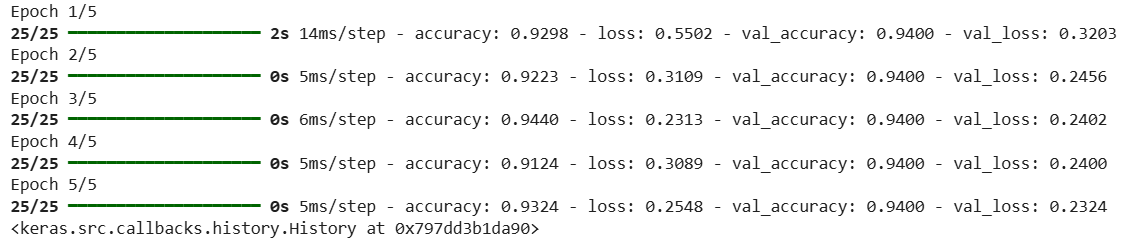

In [62]:
# Create and train the model
model_5 = create_model() # The create model function is stored into a variable called "model" which is essentially creating the model.
model_5.fit(x_train, y_train, epochs=5, validation_split=0.2)  # "model.fit" trains a model on a given dataset so here it's training on the x_train and y_train data (which was the baseball data I generated above).

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.9332 - loss: 0.5806 - val_accuracy: 0.9400 - val_loss: 0.3882
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9212 - loss: 0.3589 - val_accuracy: 0.9400 - val_loss: 0.2654
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9265 - loss: 0.2855 - val_accuracy: 0.9400 - val_loss: 0.2496
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9302 - loss: 0.2654 - val_accuracy: 0.9400 - val_loss: 0.2466
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9257 - loss: 0.2736 - val_accuracy: 0.9400 - val_loss: 0.2441


Increase the number of epochs and rerun the model on the training data and validate it to check how the model is performing (look at the loss and accuracy). Here I tried it with 25 epochs (see below).

Notice that the loss started out pretty low (67%) and ended at 22% (rates are rounded). Most of the loss decreases numerically (67%, 49%, 33%, 31%, 28%) but some of the middle values are out of order. The lowest loss was on the 23rd epoch not the 25th, but in general the loss decreased over time (the more epochs that were run). The accuracy started at 54% on epoch 1 and ended at 92% by epoch 5 (values rounded). This is a really big leap in accuracy. However it is almost identical to the ending accuracy when I ran the model with 5-epochs -the ending accuracy was also 92%. It might require increasing the number of epochs significantly, to see a larger reduction in loss and increase in accuracy.

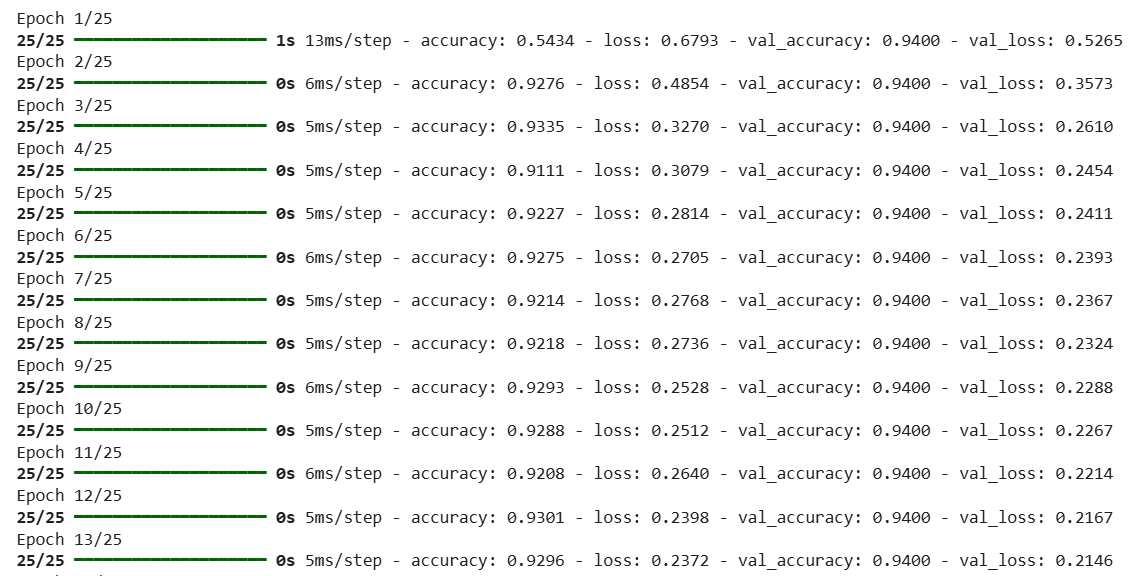

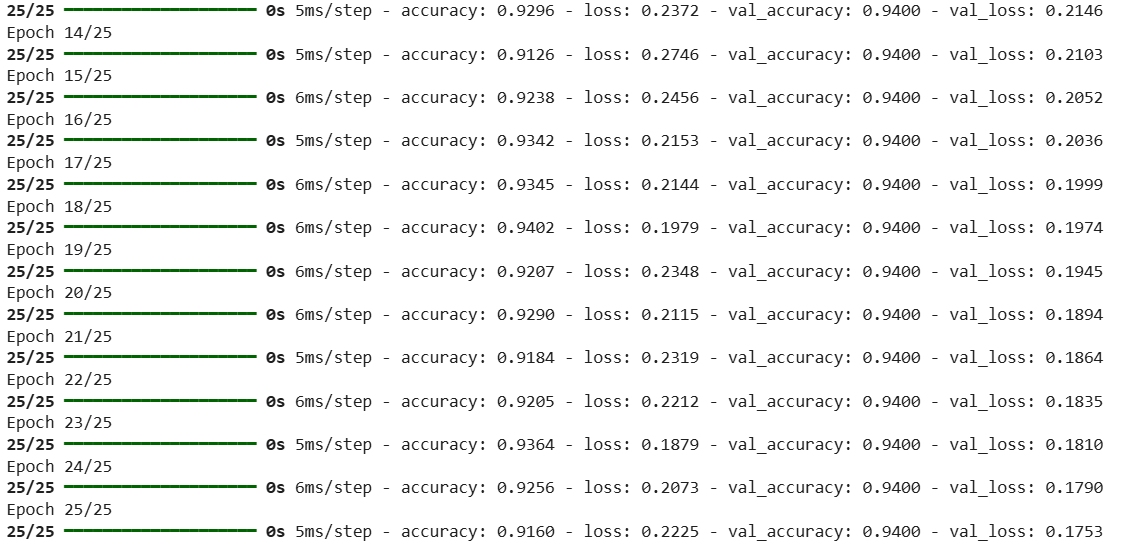

25 epochs

In [63]:
# Create and train the model
model_25 = create_model() # The create model function is stored into a variable called "model" which is essentially creating the model.
model_25.fit(x_train, y_train, epochs=25, validation_split=0.2)  # "model.fit" trains a model on a given dataset so here it's training on the x_train and y_train data.

Epoch 1/25


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8057 - loss: 0.6266 - val_accuracy: 0.9400 - val_loss: 0.4518
Epoch 2/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9109 - loss: 0.4239 - val_accuracy: 0.9400 - val_loss: 0.2799
Epoch 3/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9338 - loss: 0.2737 - val_accuracy: 0.9400 - val_loss: 0.2418
Epoch 4/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9281 - loss: 0.2681 - val_accuracy: 0.9400 - val_loss: 0.2396
Epoch 5/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9264 - loss: 0.2699 - val_accuracy: 0.9400 - val_loss: 0.2364
Epoch 6/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9201 - loss: 0.2831 - val_accuracy: 0.9400 - val_loss: 0.2335
Epoch 7/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9142 - loss: 0.2946 - val_accuracy: 0.9400 - val_loss: 0.2303
Epoch 8/25
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9268 - loss: 0.2586 - val_accuracy: 0.9400 - val_loss: 0.2254
Ep

200 epochs

Accuracy started at epoch 1 at 92.57% and ended at epoch 200 at 99.42% so the accuracy is almost perfect. It went up a lot. Loss decreased a lot, from 61.99% to 1.73%. Need to figure out when it is too many epochs vs not enough vs the right (or best) amount.

In [57]:
# Create and train the model
model = create_model() # The create model function is stored into a variable called "model" which is essentially creating the model.
model.fit(x_train, y_train, epochs=200, validation_split=0.2)  # "model.fit" trains a model on a given dataset so here it's training on the x_train and y_train data.

Epoch 1/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9257 - loss: 0.6199 - val_accuracy: 0.9400 - val_loss: 0.4599
Epoch 2/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9325 - loss: 0.4123 - val_accuracy: 0.9400 - val_loss: 0.2809
Epoch 3/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9266 - loss: 0.2912 - val_accuracy: 0.9400 - val_loss: 0.2421
Epoch 4/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9353 - loss: 0.2485 - val_accuracy: 0.9400 - val_loss: 0.2382
Epoch 5/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9083 - loss: 0.3101 - val_accuracy: 0.9400 - val_loss: 0.2339
Epoch 6/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9238 - loss: 0.2673 - val_accuracy: 0.9400 - val_loss: 0.2272
Epoch 7/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9261 - loss: 0.2582 - val_accuracy: 0.9400 - val_loss: 0.2234
Epoch 8/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9238 - loss: 0.2574 - val_accuracy: 0.9400 -

**4. Save the complete model (architecture, weights, and optimizer state) and also save just the weights.**

**3b. SAVING THE TRAINED MODEL**


**Task:** Save your trained model in two ways:

**1. Save the entire model:**  Use model.save() to create a file (e.g., baseball_model_full.h5).

**2. Save only the model weights:** Use model.save_weights() to save the weights (e.g., baseball_model.weights.h5).



**COMPLETE MODEL**

We are trying to save the model so we can reload it later without having to retrain it (since it's already been trained). In the complute or full model, saving it will save the model architecture, weights, and state of the optimizer. Saving only the weights in the model will do what it sounds like: save just the weights. I can see the full model .h5 format saved in my session files to the left in the collab session in this notebook. (see screenshot below).

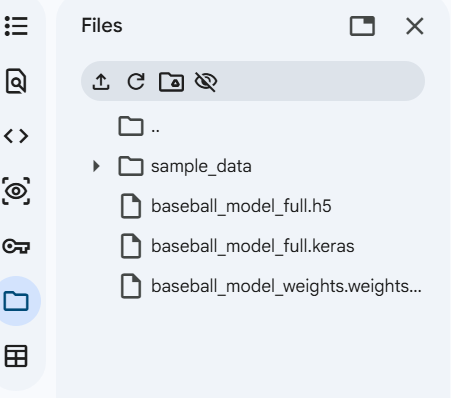

The model that was saved was the model with 5 epochs.

In [75]:
# Save the complete model (architecture + weights + optimizer state)
model_5.save('baseball_model_full.h5')
print("Full model saved as 'baseball_model_full.h5'.")  #collab didn't like this way and called it "legacy" and suggested not using .h5 but instead .keras

#other way:    (however this way didn't work when I tried to do the next code chunk to save only weights -it said it required the .h5 not .keras format)
#model.save('baseball_model_full.keras')
#print("Full Model Saved in Keras as 'baseball_model_full_keras'")



Full model saved as 'baseball_model_full.h5'.


**ONLY WEIGHTS**

Same here, the weights only model was from the model with 5 epochs.

In [76]:
# Save only the model weights
model_5.save_weights('baseball_model_weights.weights.h5')
print("Model weights saved as 'baseball_model_weights.weights.h5'.")

#other way with keras name - this way didn't work because it said the model.save_weight() function required the .h5 (not .keras) format of the full saved model then to use .weights.h5 to end the file name when using model.save_weights() function.
#model.save_weights('baseball_model_weights.keras')
#print("Model weights saved as 'baseball_model.weights.keras'.")

Model weights saved as 'baseball_model_weights.weights.h5'.


**5. Reload the saved full model and evaluate its performance on test data.**

**4b. RELOADING THE SAVED MODELS**


**Task A:** Reload the complete model from the saved file and evaluate its performance on the test data.

**Load Complete Model.**

In [77]:
# Load the complete model
loaded_model_5 = keras.models.load_model('baseball_model_full.h5')

**Evaluate reloaded model with test data.**

The accuracy this time is 89.50% (for the full model reloaded).

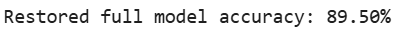

In [78]:
# Evaluate the reloaded model on the test data
loss, accuracy = loaded_model_5.evaluate(x_test, y_test, verbose=0) #must use a model.evaluate or model.fit or model.compile after reloading a full model in order to then do the metrics like accuracy or loss, or other items. So here we do the model.evaluate function.
print("Restored full model accuracy: {:.2f}%".format(100 * accuracy))

Restored full model accuracy: 89.50%


**Task B:** Rebuild the model architecture by calling the create_model() function and then load the saved weights. Evaluate this model on the test data.

We expect the accuracy to be the same for the original full model that is reloaded and for the weights only model that is reloaded because the weights only model loads the trained weights into the new model so now it should have the same architecture from the original full model that was saved. In this case both of the accuraces (from the full model reloaded and the reloaded weights model) are both 89.5%.

image.png

In [79]:
# Recreate the model architecture
new_model = create_model()

# Load the saved weights into the newly recreated model
new_model.load_weights('baseball_model_weights.weights.h5')

# Evaluate the model with reloaded weights
loss, accuracy = new_model.evaluate(x_test, y_test, verbose=0)
print("Model with reloaded weights accuracy: {:.2f}%".format(100 * accuracy))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model with reloaded weights accuracy: 89.50%


**5. Experimentation and Questions**

As part of the assignment, answer the following questions in a text cell in your Colab notebook:

**Reflection:**

What are the benefits of saving the full model versus only saving the weights?

Describe a scenario in which one approach might be more advantageous than the other.



**Analysis:**

Compare the performance of the reloaded full model and the weights-only model. Were there any differences? If so, why might that be?

The performance was measured by accuracy, because when we created the model prior to using the datasets we created, we chose the optimizer and the metric to measure model performance and we chose to set it as "accuracy". The accuracy for both the reloaded full model and the weights only model were the same (both were 89.5%). We would expect them to be the same and there were no differences. The reloaded weights model should reload the trained weights then load it into the new model and it will come out with the same architecture as the original saved full model that was reloaded. IF the models both have the same architecture, the same trained weights and the same optimizer we would expect them to essentially be the same model and now perform the same and have the same accuracy.

**Extension (optional):**

Modify the model architecture slightly (e.g., change the number of neurons in one hidden layer) and try reloading the weights. What happens when the architecture does not match?

Code chunks below show changing the number of neurons in the hidden layer from 64 to 12, so they don't match from the original model that saved the weights to the current model.

In [80]:
def create_model():
    model_modified = keras.Sequential([
        keras.layers.Dense(64, activation='relu', input_shape=(2,)), #input layer with 2 features
        keras.layers.Dense(12, activation='relu'), #hidden layer with 64 neurons and relu activation function
        keras.layers.Dense(1, activation='sigmoid') #output layer with sigmoid activation function and it has a binary classification as the output 0 or 1 essentially.
    ])
    model_modified.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model_modified

In [82]:
# Create and train the model (5 epochs)
model_mod = create_model() # The create model function is stored into a variable called "model" which is essentially creating the model.
model_mod.fit(x_train, y_train, epochs=5, validation_split=0.2)  # "model.fit" trains a model on a given dataset so here it's training on the x_train and y_t

Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.8372 - loss: 0.6181 - val_accuracy: 0.9400 - val_loss: 0.4761
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9155 - loss: 0.4478 - val_accuracy: 0.9400 - val_loss: 0.3402
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9248 - loss: 0.3324 - val_accuracy: 0.9400 - val_loss: 0.2705
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9355 - loss: 0.2675 - val_accuracy: 0.9400 - val_loss: 0.2529
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9344 - loss: 0.2607 - val_accuracy: 0.9400 - val_loss: 0.2465


In [83]:
# Save the complete model (architecture + weights + optimizer state)
model_mod.save('baseball_model_mod_full.h5')
print("Full model saved as 'baseball_model_mod_full.h5'.")

Full model saved as 'baseball_model_mod_full.h5'.


In [84]:
# Save only the model weights
model_mod.save_weights('baseball_model_mod_weights.weights.h5')
print("Model weights saved as 'baseball_model_mod_weights.weights.h5'.")

Model weights saved as 'baseball_model_mod_weights.weights.h5'.


In [85]:
# Load the complete/full modified model
loaded_model_mod = keras.models.load_model('baseball_model_full.h5')

In [86]:
# Evaluate the reloaded model on the test data
loss, accuracy = loaded_model_mod.evaluate(x_test, y_test, verbose=0) #must use a model.evaluate or model.fit or model.compile after reloading a full model in order to then do the metrics like accuracy or loss, or other items. So here we do the model.evaluate function.
print("Restored full model accuracy: {:.2f}%".format(100 * accuracy))

Restored full model accuracy: 89.50%


In [87]:
# Recreate the model architecture
new_model_mod = create_model()

# Load the saved weights into the newly recreated model
new_model_mod.load_weights('baseball_model_weights.weights.h5')

# Evaluate the model with reloaded weights
loss, accuracy = new_model_mod.evaluate(x_test, y_test, verbose=0)
print("Model with reloaded weights accuracy: {:.2f}%".format(100 * accuracy))

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


ValueError: A total of 2 objects could not be loaded. Example error message for object <Dense name=dense_43, built=True>:

The shape of the target variable and the shape of the target value in `variable.assign(value)` must match. variable.shape=(64, 12), Received: value.shape=(64, 64). Target variable: <Variable path=sequential_14/dense_43/kernel, shape=(64, 12), dtype=float32, value=[[ 0.24958214 -0.00632513 -0.02952129 -0.27803814  0.10067394  0.05890417
   0.24268666  0.18793127 -0.13967006 -0.03573801  0.11087507 -0.26055843]
 [ 0.13228676 -0.09793237  0.12081724 -0.23462258  0.04244182  0.13761032
   0.11686724  0.14693162  0.18273044 -0.03002369  0.09378716  0.1598638 ]
 [-0.16637614  0.04563367 -0.02944016 -0.03825454  0.13635868 -0.2234756
   0.16649547  0.2695277   0.10555112 -0.22276177  0.07320416 -0.09089997]
 [-0.16708906 -0.23970711  0.16716677  0.06943595  0.19720963 -0.13042653
   0.10548159 -0.01142392  0.24036732  0.00566164  0.10583919  0.11599451]
 [-0.09806454  0.1

**Answer:** In the code chunk above, when trying to reload the weights after the number of neurons in the original model was changed from 64 to 12 in the hidden layer, it got an error that said "List of objects that could not be loaded:
[<Dense name=dense_43, built=True>, <Dense name=dense_44, built=True>]" and it listed the items that couldn't reload.
Keras expected that the number of neurons in the hidden layer in the original model that the weights were saved would match the number of neurons in the hidden layer in my current model, but they don't match so there is an error that is a shape mismatch error. It lists things that are wrong, essentially the expected siave the of the weight matrices is not the same between the original saved model with the trained weights and the new model (because the number of neurons don't match meaning the architecture is different). To have the same architecture you have to also have the same number of neurons in each layer, amonst other items that must be the same (number of features, etc.).

**SUBMISSION INSTRUCTIONS**

**Notebook File:** Submit your completed Google Colab notebook file (LastNameMod03.ipynb where LastName is your last name ex: ArringtonMod03.ipynb)  that contains:

All code cells with your implementation for data generation, model building, training, saving, and reloading.

Text cells with your responses to the reflective questions.

**Execution:** Ensure your notebook runs without errors and that all output (including accuracy results) is visible.

**Documentation:** Include comments in your code to explain key steps and logic.